# **Research Question 1**

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, f_oneway
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from pathlib import Path

## EDA

In [2]:
cdi = pd.read_csv("U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv", low_memory=False)
cvd = cdi.rename(columns={"LocationID": "statefips", "YearStart": "year"})

cvd = (
    cvd[
        (cvd["Topic"] == "Cardiovascular Disease") &
        (cvd["DataValueType"] == "Age-adjusted Rate") &
        (cvd["LocationAbbr"] != "US") &
        (cvd["StratificationCategory1"] == "Overall") &
        (cvd["year"].between(2011, 2014))
    ]
    .rename(columns={'DataValue': 'cvd_rate'})
    [['year', 'statefips', 'Question', 'cvd_rate']]
    .dropna()
)
cvd.head()

,year,statefips,Question,cvd_rate
276777,2011,1,Mortality from total cardiovascular diseases,298.5
292388,2013,6,Mortality from total cardiovascular diseases,206.0
297352,2014,19,Mortality from total cardiovascular diseases,209.0
299718,2014,13,Mortality from total cardiovascular diseases,241.9
303297,2011,21,Mortality from total cardiovascular diseases,272.2


In [3]:
oz = pd.read_csv("Daily_Census_Tract-Level_Ozone_Concentrations,_2011-2014_20251123.csv")
oz = oz.rename(columns={'avg_ds_o3_pred': 'ozone_avg'})
oz.head()

,year,statefips,ozone_avg
0,2011,1,41.188464
1,2011,10,40.292219
2,2011,11,39.648261
3,2011,12,38.326634
4,2011,13,42.859011


In [4]:
# Merge with ozone
df = pd.merge(cvd, oz, on=['year','statefips'], how='inner')
df['Ozone_quartile'] = pd.qcut(df['ozone_avg'], 4, labels=['Q1','Q2','Q3','Q4'])
df['cvd_rate'] = pd.to_numeric(df['cvd_rate'], errors='coerce')
df['ozone_avg'] = pd.to_numeric(df['ozone_avg'], errors='coerce')
df.head()

,year,statefips,Question,cvd_rate,ozone_avg,Ozone_quartile
0,2011,1,Mortality from total cardiovascular diseases,298.5,41.188464,Q4
1,2013,6,Mortality from total cardiovascular diseases,206.0,40.421595,Q3
2,2014,19,Mortality from total cardiovascular diseases,209.0,35.889794,Q1
3,2014,13,Mortality from total cardiovascular diseases,241.9,38.028749,Q2
4,2011,21,Mortality from total cardiovascular diseases,272.2,41.300778,Q4


## Multiple Hypothesis Testing

In [5]:
# Multiple hypothesis testing / Decision Making

# Aggregate by state-year to remove duplicates
df_agg = df.groupby(['year','statefips']).agg({
    'cvd_rate': 'mean',
    'ozone_avg': 'mean'}).reset_index()

# Assign year-specific quartiles
df_agg['Ozone_quartile'] = df_agg.groupby('year')['ozone_avg']\
                                 .transform(lambda x: pd.qcut(x, 4, labels=['Q1','Q2','Q3','Q4']))

summary_stats = df_agg.groupby('Ozone_quartile', observed=True)['cvd_rate'].agg(['mean','std','count'])
print("=== Summary Statistics by Ozone Quartile ===")
print(summary_stats)

=== Summary Statistics by Ozone Quartile ===
                      mean        std  count
Ozone_quartile                              
Q1               94.775633  16.591409     52
Q2              105.693082  16.722995     48
Q3              107.594939  16.244448     48
Q4               99.797413  20.837221     48


### Visualizations

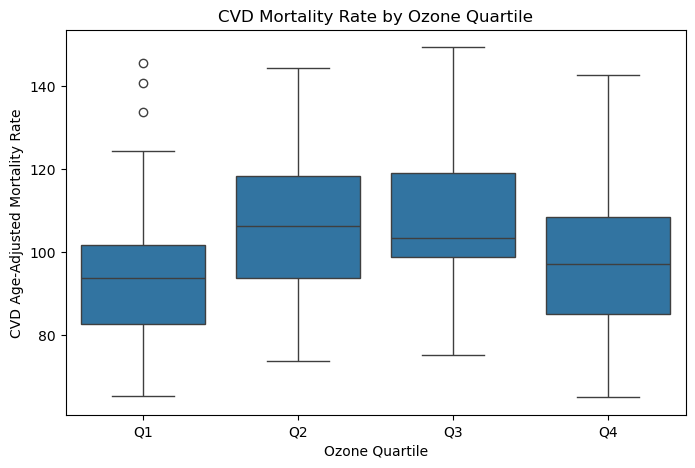

In [6]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Ozone_quartile', y='cvd_rate', data=df_agg)
plt.title('CVD Mortality Rate by Ozone Quartile')
plt.ylabel('CVD Age-Adjusted Mortality Rate')
plt.xlabel('Ozone Quartile')
plt.show()

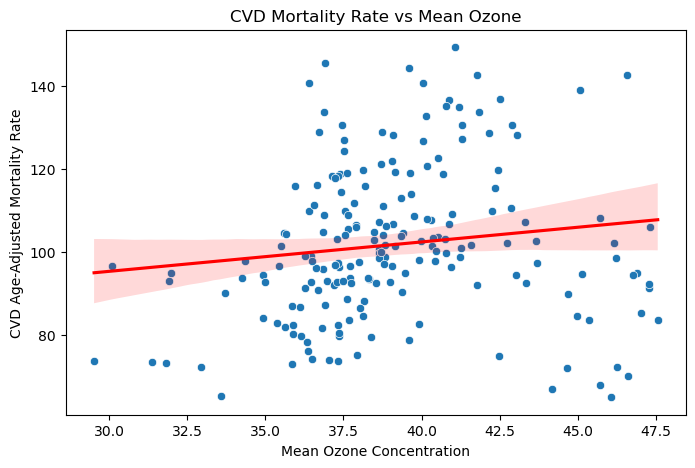

In [7]:
# Scatter plot with linear fit
plt.figure(figsize=(8,5))
sns.scatterplot(x='ozone_avg', y='cvd_rate', data=df_agg)
sns.regplot(x='ozone_avg', y='cvd_rate', data=df_agg, scatter=False, color='red')
plt.title('CVD Mortality Rate vs Mean Ozone')
plt.xlabel('Mean Ozone Concentration')
plt.ylabel('CVD Age-Adjusted Mortality Rate')
plt.show()

In [8]:
# Define six pairwise hypotheses
comparisons = [
    ('Q4', 'Q1'),
    ('Q3', 'Q1'),
    ('Q2', 'Q1'),
    ('Q4', 'Q2'),
    ('Q4', 'Q3'),
    ('Q3', 'Q2')
]

# Perform t-tests
results = []

for q_high, q_low in comparisons:
    group_high = df_agg[df_agg['Ozone_quartile'] == q_high]['cvd_rate']
    group_low = df_agg[df_agg['Ozone_quartile'] == q_low]['cvd_rate']

    t_stat, p_val = ttest_ind(group_high, group_low, equal_var=False)

    results.append({
        'Comparison': f"{q_high} vs {q_low}",
        't-statistic': t_stat,
        'p-value': p_val,
        'Mean_high': group_high.mean() if len(group_high) > 0 else np.nan,
        'Mean_low': group_low.mean() if len(group_low) > 0 else np.nan,
        'Std_high': group_high.std() if len(group_high) > 0 else np.nan,
        'Std_low': group_low.std() if len(group_low) > 0 else np.nan,
        'N_high': len(group_high),
        'N_low': len(group_low)
    })

results_df = pd.DataFrame(results)
results_df

,Comparison,t-statistic,p-value,Mean_high,Mean_low,Std_high,Std_low,N_high,N_low
0,Q4 vs Q1,1.326150,0.188154,99.797413,94.775633,20.837221,16.591409,48,52
1,Q3 vs Q1,3.902364,0.000175,107.594939,94.775633,16.244448,16.591409,48,52
2,Q2 vs Q1,3.273930,0.001470,105.693082,94.775633,16.722995,16.591409,48,52
3,Q4 vs Q2,-1.528800,0.129829,99.797413,105.693082,20.837221,16.722995,48,48
4,Q4 vs Q3,-2.044690,0.043849,99.797413,107.594939,20.837221,16.244448,48,48
5,Q3 vs Q2,0.565175,0.573303,107.594939,105.693082,16.244448,16.722995,48,48


In [9]:
# Multiple testing corrections

# Bonferroni
bonf = multipletests(results_df['p-value'], alpha=0.05, method='bonferroni')
results_df['p-value_Bonferroni'] = bonf[1]
results_df['Significant_Bonferroni'] = bonf[0]

# Benjamini-Hochberg (FDR)
fdr = multipletests(results_df['p-value'], alpha=0.05, method='fdr_bh')
results_df['p-value_FDR'] = fdr[1]
results_df['Significant_FDR'] = fdr[0]

print("\n=== Pairwise T-Test Results ===")
display_cols = ['Comparison', 't-statistic', 'p-value', 'p-value_Bonferroni',
                'Significant_Bonferroni', 'p-value_FDR', 'Significant_FDR',
                'Mean_high','Mean_low']
print(results_df[display_cols])


=== Pairwise T-Test Results ===
  Comparison  t-statistic   p-value  p-value_Bonferroni  \
0   Q4 vs Q1     1.326150  0.188154            1.000000   
1   Q3 vs Q1     3.902364  0.000175            0.001051   
2   Q2 vs Q1     3.273930  0.001470            0.008818   
3   Q4 vs Q2    -1.528800  0.129829            0.778976   
4   Q4 vs Q3    -2.044690  0.043849            0.263094   
5   Q3 vs Q2     0.565175  0.573303            1.000000   

   Significant_Bonferroni  p-value_FDR  Significant_FDR   Mean_high  \
0                   False     0.225785            False   99.797413   
1                    True     0.001051             True  107.594939   
2                    True     0.004409             True  105.693082   
3                   False     0.194744            False   99.797413   
4                   False     0.087698            False   99.797413   
5                   False     0.573303            False  107.594939   

     Mean_low  
0   94.775633  
1   94.775633  
2   94.

In [10]:
# Effect size & power (Q4 vs Q1)

group_Q4 = df_agg[df_agg['Ozone_quartile'] == 'Q4']['cvd_rate']
group_Q1 = df_agg[df_agg['Ozone_quartile'] == 'Q1']['cvd_rate']

mean_diff = group_Q4.mean() - group_Q1.mean()
std_Q4 = group_Q4.std()
std_Q1 = group_Q1.std()
n_Q4 = len(group_Q4)
n_Q1 = len(group_Q1)

# Pooled SD for Cohen's d
std_pooled = np.sqrt(((n_Q4-1)*std_Q4**2 + (n_Q1-1)*std_Q1**2) / (n_Q4+n_Q1-2))
cohens_d = mean_diff / std_pooled

# Power analysis (two-sided)
power_analysis = TTestIndPower()
power = power_analysis.solve_power(
    effect_size=cohens_d,
    nobs1=n_Q4,
    alpha=0.05,
    ratio=n_Q1/n_Q4,
    alternative='two-sided'
)

print("\n=== Effect Size & Power for Q4 vs Q1 ===")
print(f"Mean Q4 = {group_Q4.mean():.2f}, Mean Q1 = {group_Q1.mean():.2f}")
print(f"Std Q4 = {std_Q4:.2f}, Std Q1 = {std_Q1:.2f}")
print(f"N Q4 = {n_Q4}, N Q1 = {n_Q1}")
print(f"Observed mean difference = {mean_diff:.2f}")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"Power (alpha = 0.05, two-sided) = {power:.3f}")


=== Effect Size & Power for Q4 vs Q1 ===
Mean Q4 = 99.80, Mean Q1 = 94.78
Std Q4 = 20.84, Std Q1 = 16.59
N Q4 = 48, N Q1 = 52
Observed mean difference = 5.02
Cohen's d = 0.268
Power (alpha = 0.05, two-sided) = 0.263


# **Research Question 2**

## EDA

In [13]:
# get rid of national rows
restrict_state = ~cdi["LocationAbbr"].isin(["US", "PR"])

added_restrictions = (cdi["StratificationCategory1"].str.contains("Overall", case=False, na=False)| cdi["Stratification1"].str.contains("Overall", case=False, na=False)
| cdi["StratificationCategory1"].isna())

cdi_state = cdi[restrict_state & added_restrictions].copy()
print(cdi_state.shape)

(161345, 34)


In [14]:
high_bp = cdi_state[(cdi_state["Topic"] == "Cardiovascular Disease") & (cdi_state["Question"].str.contains("high blood pressure among adults",
case=False, na=False)) & (cdi_state["DataValueType"] == "Age-adjusted Prevalence")].copy()

high_bp = high_bp[["YearStart", "LocationAbbr", "DataValue"]].rename(columns={"YearStart": "year","LocationAbbr": "state", "DataValue": "high_bp_prev",})
high_bp["high_bp_prev"] = pd.to_numeric(high_bp["high_bp_prev"], errors="coerce")

print(high_bp.shape)
high_bp.head()

(318, 3)


,year,state,high_bp_prev
530586,2019,AK,32.8
531571,2015,AK,28.5
532253,2011,AK,31.0
534551,2017,AK,32.3
534619,2013,AK,30.3


In [15]:
smoke = cdi_state[(cdi_state["Topic"] == "Tobacco") & (cdi_state["Question"].str.contains("current smoking among adults", case=False, na=False)) &
(cdi_state["DataValueType"] == "Age-adjusted Prevalence")].copy()

smoke = smoke[["YearStart", "LocationAbbr", "DataValue"]].rename(columns={"YearStart": "year", "LocationAbbr": "state", "DataValue": "smoking_prev"})
smoke["smoking_prev"] = pd.to_numeric(smoke["smoking_prev"], errors="coerce")


print(smoke.shape)
smoke.head()

(583, 3)


,year,state,smoking_prev
531128,2018,AK,18.7
531489,2012,AK,20.0
532816,2016,AK,18.7
534155,2014,AK,19.5
534181,2019,AK,17.6


In [16]:
high_bp_panel = (high_bp.groupby(["state", "year"], as_index=False)["high_bp_prev"].mean())

smoke_panel = (smoke.groupby(["state", "year"], as_index=False)["smoking_prev"].mean())

print("High BP panel:", high_bp_panel.shape)
print("Smoking panel:", smoke_panel.shape)

High BP panel: (318, 3)
Smoking panel: (583, 3)


In [17]:
panel = pd.merge(high_bp_panel, smoke_panel, on=["state", "year"], how="inner")

panel = panel.dropna(subset=["high_bp_prev", "smoking_prev"]).copy()
print("Years:", sorted(panel["year"].unique()))
print("Num of states:", panel["state"].nunique())
panel.head()

Years: [2011, 2013, 2015, 2017, 2019, 2021]
Num of states: 52


,state,year,high_bp_prev,smoking_prev
0,AK,2011,31.0,22.1
1,AK,2013,30.3,22.1
2,AK,2015,28.5,18.4
3,AK,2017,32.3,20.9
4,AK,2019,32.8,17.6


In [18]:
state_codes = np.sort(panel["state"].unique())

state_to_idx = {}
for i, s in enumerate(state_codes):
    state_to_idx[s] = i

panel["state_idx"] = panel["state"].map(state_to_idx)

year_mean = panel["year"].mean()
panel["year_c"] = panel["year"] - year_mean

smoke_mean = panel["smoking_prev"].mean()
panel["smoke_centered"] = panel["smoking_prev"] - smoke_mean

scale_factor = 5.0
panel["smoke_scaled"] = panel["smoke_centered"] / scale_factor

cols_to_show = ["state", "year", "high_bp_prev", "smoking_prev", "smoke_scaled", "year_c"]
panel[cols_to_show].head()

,state,year,high_bp_prev,smoking_prev,smoke_scaled,year_c
0,AK,2011,31.0,22.1,0.749226,-4.974194
1,AK,2013,30.3,22.1,0.749226,-2.974194
2,AK,2015,28.5,18.4,0.009226,-0.974194
3,AK,2017,32.3,20.9,0.509226,1.025806
4,AK,2019,32.8,17.6,-0.150774,3.025806


In [19]:
state_idx = panel["state_idx"].values
smoke_scaled = panel["smoke_scaled"].values
year_c = panel["year_c"].values
y = panel["high_bp_prev"].values

n_states = panel["state_idx"].nunique()
n_states

52

In [20]:
# Descriptive stats for key variables in the panel
desc_stats = panel[["high_bp_prev", "smoking_prev", "smoke_scaled", "year_c"]].describe()
print("Descriptive statistics for key variables:")
print(desc_stats)

# Correlation matrix between BP, smoking, and year
corr = panel[["high_bp_prev", "smoking_prev", "year"]].corr()
print("\nCorrelation matrix:")
print(corr)

Descriptive statistics for key variables:
       high_bp_prev  smoking_prev  smoke_scaled        year_c
count    310.000000    310.000000  3.100000e+02  3.100000e+02
mean      30.540645     18.353871  4.268987e-16 -2.347083e-14
std        3.712782      4.245199  8.490398e-01  3.416026e+00
min       23.500000      7.300000 -2.210774e+00 -4.974194e+00
25%       27.900000     15.500000 -5.707742e-01 -2.974194e+00
50%       29.700000     18.000000 -7.077419e-02 -9.741935e-01
75%       32.075000     21.200000  5.692258e-01  3.025806e+00
max       41.200000     30.200000  2.369226e+00  5.025806e+00

Correlation matrix:
              high_bp_prev  smoking_prev      year
high_bp_prev      1.000000      0.585276  0.028355
smoking_prev      0.585276      1.000000 -0.483744
year              0.028355     -0.483744  1.000000


## Visualizations

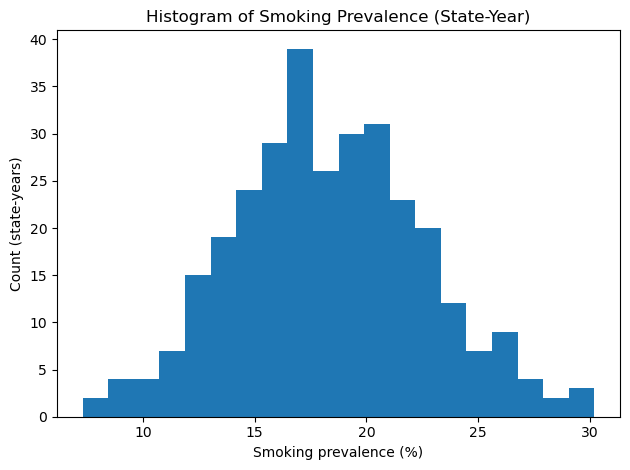

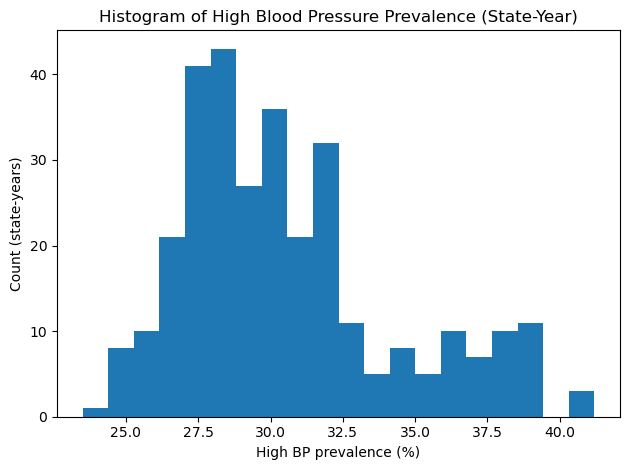

In [21]:
# Histogram of smoking prevalence
plt.figure()
plt.hist(panel["smoking_prev"].dropna(), bins=20)
plt.xlabel("Smoking prevalence (%)")
plt.ylabel("Count (state-years)")
plt.title("Histogram of Smoking Prevalence (State-Year)")
plt.tight_layout()
plt.show()

# Histogram of high blood pressure prevalence
plt.figure()
plt.hist(panel["high_bp_prev"].dropna(), bins=20)
plt.xlabel("High BP prevalence (%)")
plt.ylabel("Count (state-years)")
plt.title("Histogram of High Blood Pressure Prevalence (State-Year)")
plt.tight_layout()
plt.show()

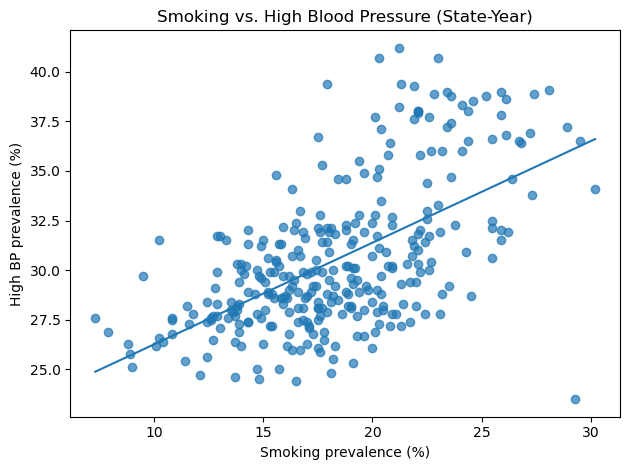

In [22]:
plt.figure()
plt.scatter(panel["smoking_prev"], panel["high_bp_prev"], alpha=0.7)

m, b = np.polyfit(panel["smoking_prev"], panel["high_bp_prev"], 1)
x_vals = np.linspace(panel["smoking_prev"].min(), panel["smoking_prev"].max(), 100)
plt.plot(x_vals, m * x_vals + b)

plt.xlabel("Smoking prevalence (%)")
plt.ylabel("High BP prevalence (%)")
plt.title("Smoking vs. High Blood Pressure (State-Year)")
plt.tight_layout()
plt.show()

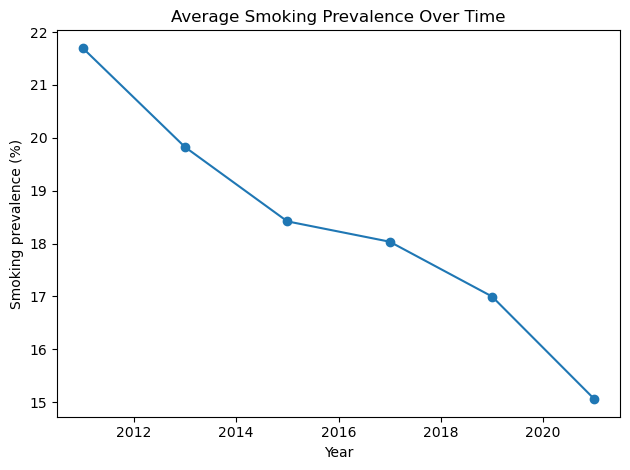

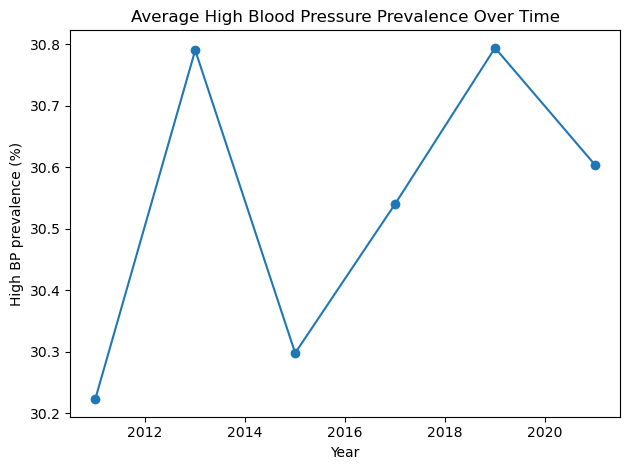

In [23]:
avg_by_year = panel.groupby("year")[["high_bp_prev", "smoking_prev"]].mean().reset_index()

# Smoking over time
plt.figure()
plt.plot(avg_by_year["year"], avg_by_year["smoking_prev"], marker="o")
plt.xlabel("Year")
plt.ylabel("Smoking prevalence (%)")
plt.title("Average Smoking Prevalence Over Time")
plt.tight_layout()
plt.show()

# High blood pressure over time
plt.figure()
plt.plot(avg_by_year["year"], avg_by_year["high_bp_prev"], marker="o")
plt.xlabel("Year")
plt.ylabel("High BP prevalence (%)")
plt.title("Average High Blood Pressure Prevalence Over Time")
plt.tight_layout()
plt.show()

Overall variance in BP prevalence: 13.784750391481367
Between-state variance: 12.903036747947041
Average within-state variance: 1.2174615384615384
ICC (share of variance between states): 0.9137805540734081


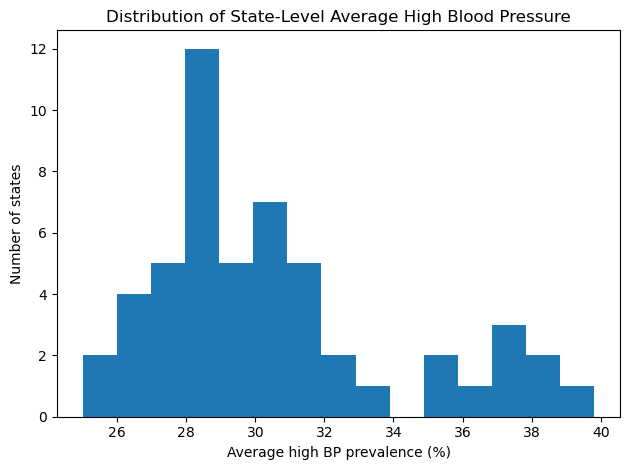

In [24]:
# Decompose variance of high_bp_prev
overall_var = panel["high_bp_prev"].var()

state_means = panel.groupby("state")["high_bp_prev"].mean()
between_var = state_means.var()

within_var_by_state = panel.groupby("state")["high_bp_prev"].var()
within_var = within_var_by_state.mean()

icc = between_var / (between_var + within_var)

print("Overall variance in BP prevalence:", overall_var)
print("Between-state variance:", between_var)
print("Average within-state variance:", within_var)
print("ICC (share of variance between states):", icc)

# Plot distribution of state average BP levels
plt.figure()
plt.hist(state_means.values, bins=15)
plt.xlabel("Average high BP prevalence (%)")
plt.ylabel("Number of states")
plt.title("Distribution of State-Level Average High Blood Pressure")
plt.tight_layout()
plt.show()

## Bayesian Hierarchical Model

In [25]:
with pm.Model() as bp_smoke_model:
    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=5.0)

    alpha_state = pm.Normal("alpha_state", mu=mu_alpha, sigma=sigma_alpha, shape=n_states)

    beta_smoke = pm.Normal("beta_smoke", mu=0.0, sigma=1.0)
    gamma_year = pm.Normal("gamma_year", mu=0.0, sigma=1.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    mu = alpha_state[state_idx] + beta_smoke * smoke_scaled + gamma_year * year_c
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    idata = pm.sample(draws=2000, tune=2000, chains=4,target_accept=0.95, random_seed=123)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_state, beta_smoke, gamma_year, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 16 seconds.


In [26]:
beta_samples = idata.posterior["beta_smoke"].values.flatten()

point_est = np.percentile(beta_samples, 50)
ci_low, ci_high = np.percentile(beta_samples, [2.5, 97.5])

print("Estimated change in high BP prevalence for a 5-pt increase in smoking prevalence:")
print(f"Posterior median: {point_est:.2f} percentage points")
print(f"95% credible interval: [{ci_low:.2f}, {ci_high:.2f}]")

Estimated change in high BP prevalence for a 5-pt increase in smoking prevalence:
Posterior median: 1.15 percentage points
95% credible interval: [0.51, 1.84]


In [27]:
with pm.Model() as bp_smoke_model_wide:
    mu_alpha_wide = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
    sigma_alpha_wide = pm.HalfNormal("sigma_alpha", sigma=5.0)

    alpha_state_wide = pm.Normal("alpha_state", mu=mu_alpha_wide, sigma=sigma_alpha_wide, shape=n_states)

    beta_smoke_wide = pm.Normal("beta_smoke", mu=0.0, sigma=5.0)
    gamma_year_wide = pm.Normal("gamma_year", mu=0.0, sigma=1.0)
    sigma_wide = pm.HalfNormal("sigma", sigma=1.0)

    mu_wide = alpha_state_wide[state_idx] + beta_smoke_wide * smoke_scaled + gamma_year_wide * year_c

    y_obs_wide = pm.Normal("y_obs", mu=mu_wide, sigma=sigma_wide, observed=y)

    idata_wide = pm.sample(draws=2000, tune=2000, chains=4,target_accept=0.95, random_seed=123)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_state, beta_smoke, gamma_year, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 17 seconds.


In [28]:
beta_w = idata_wide.posterior["beta_smoke"].values.flatten()

point_est_w = np.percentile(beta_w, 50)
ci_low_w, ci_high_w = np.percentile(beta_w, [2.5, 97.5])

print("Wide prior results:")
print(f"Posterior median: {point_est_w:.2f} percentage points")
print(f"95% credible interval: [{ci_low_w:.2f}, {ci_high_w:.2f}]")

Wide prior results:
Posterior median: 1.34 percentage points
95% credible interval: [0.61, 2.02]


### Posterior Summaries

In [29]:
print("Posterior summary for baseline model:")
az.summary(
    idata,
    var_names=["mu_alpha", "sigma_alpha", "beta_smoke", "gamma_year", "sigma"],
    round_to=2)

Posterior summary for baseline model:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,30.31,0.45,29.46,31.15,0.01,0.01,7240.91,5404.16,1.00
sigma_alpha,3.08,0.35,2.46,3.76,0.01,0.00,3168.31,4666.01,1.00
beta_smoke,1.16,0.34,0.53,1.81,0.01,0.01,1015.43,2129.64,1.01
gamma_year,0.17,0.05,0.09,0.26,0.00,0.00,1172.76,2244.88,1.00
sigma,1.11,0.05,1.02,1.21,0.00,0.00,5472.60,5731.62,1.00


In [30]:
print("Posterior summary for wide beta_smoke prior model:")
az.summary(
    idata_wide,
    var_names=["mu_alpha", "sigma_alpha", "beta_smoke", "gamma_year", "sigma"],
    round_to=2)

Posterior summary for wide beta_smoke prior model:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,30.32,0.42,29.53,31.12,0.00,0.01,10390.12,6197.54,1.00
sigma_alpha,3.01,0.35,2.36,3.64,0.01,0.00,3428.46,4604.24,1.00
beta_smoke,1.33,0.37,0.68,2.02,0.01,0.01,1164.01,2099.12,1.01
gamma_year,0.19,0.05,0.10,0.28,0.00,0.00,1282.52,2616.81,1.01
sigma,1.12,0.05,1.02,1.22,0.00,0.00,5573.46,5321.40,1.00
